20.602041703090325
20.684
Média de iterações do Jacobi = 13.394166666666667

Método | Tempo [s] | Erro [%]
TDMA | 0.5076982975006104 | 0.0003995717022255113
Gauss | 39.469582319259644 | 0.00039957170215873566
Jacobi | 57.59939217567444 | 0.00041097594206709626
Scipy | 0.22769594192504883 | 0.0003995717021899833


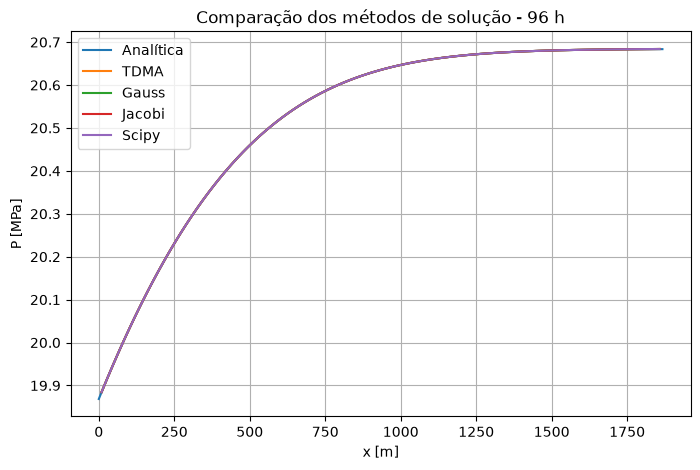

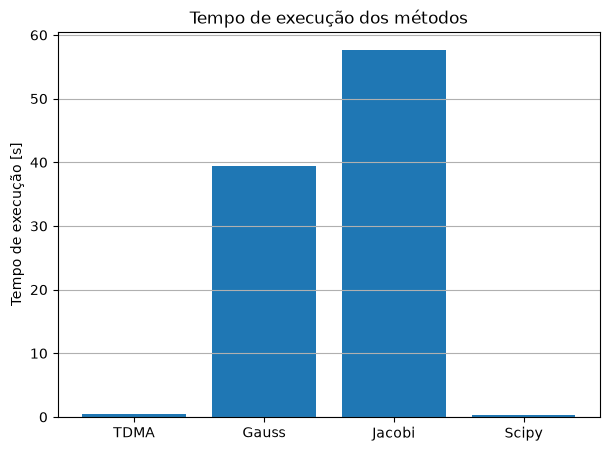

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

from analytical.transiente_L1d_FP import linear_trans_1d_FP
from mdf.implicita import implicita_1d_FP
from core.erros import erro_L1_relativo


# parâmetros

p0 = 20.684e6
Pe = p0

A_R = 3484800
L = np.sqrt(A_R)

qw = 4.968e-3

k = 339 * 9.869233e-16
phi = 0.22
ct = 3.046e-9
mu = 1.0e-3

h = 4.572
largura = L
A = h * largura

t_h = 96
t_final = t_h * 3600

eta = k / (phi * ct * mu)

nx = 100
nt = 1200


# solução analítica

x_an, t_an, X, T, P_an = linear_trans_1d_FP(p0, qw, L, k, A, mu, eta, t_final)


# métodos

metodos = ["TDMA", "Gauss", "Jacobi", "Scipy"]

tempos = []
solucoes = []


for metodo in metodos:

    inicio = time.time()

    x, t, P, _ = implicita_1d_FP(p0, Pe, -qw, h, L, largura, k, phi, ct, mu, t_final, nx, nt, metodo=metodo)

    tempos.append(time.time() - inicio)
    solucoes.append(P[-1, :])


# solução analítica na malha numérica

P_ref = np.interp(x, x_an, P_an[-1, :])


# resultados

print("\nMétodo | Tempo [s] | Erro [%]")

for metodo, tempo, P in zip(metodos, tempos, solucoes):

    erro_percentual = (erro_L1_relativo(P_ref, P) / len(P_ref)) * 100

    print(metodo, "|", tempo, "|", erro_percentual)


# gráfico das soluções

plt.figure(figsize=(8, 5))

plt.plot(x_an, P_an[-1, :] / 1e6, label="Analítica")

for metodo, P in zip(metodos, solucoes):

    plt.plot(x, P / 1e6, label=metodo)

plt.xlabel("x [m]")
plt.ylabel("P [MPa]")
plt.title("Comparação dos métodos de solução - 96 h")

plt.legend()
plt.grid()
plt.show()


# gráfico do tempo de execução

plt.figure(figsize=(7, 5))

plt.bar(metodos, tempos)

plt.ylabel("Tempo de execução [s]")
plt.title("Tempo de execução dos métodos")

plt.grid(axis="y")
plt.show()